# German Credit Risk: Modeling and Hyperparameter Optimization

This notebook focuses on building the machine learning pipeline, exploring baseline models, optimizing hyperparameters using Optuna, and evaluating the final model.

In [1]:
# Add parent directory to path to import src
import sys
import os
sys.path.append(os.path.abspath('..'))

import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import optuna

# Import custom modules
from src import config, preprocessing, visualization, modeling

# Set plot style
visualization.set_style()

## 1. Data Loading and Preparation

Reload and prepare the data as done in the previous notebook.

In [2]:
# Load data
df = preprocessing.load_data()

# Clean and prepare
df = preprocessing.clean_column_names(df, config.RENAME_MAPPING)
df = preprocessing.decode_categorical_features(df, config.VALUE_MAPPINGS)
df = preprocessing.encode_target(df, target_col='Target', mapping=config.TARGET_MAPPING)

# Split into X and y
X = df.drop(columns=['Target'])
y = df['Target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

🔄 Fetching dataset from UCI repository (ID=144)...
✅ Dataset loaded successfully! Shape: (1000, 21)
✅ Columns renamed successfully!
✅ Categorical values decoded successfully!
✅ Target variable 'Target' transformed!
Training set shape: (800, 20)
Test set shape: (200, 20)


## 2. Baseline Models

Evaluate baseline models using specific feature sets for binning and scaling.

In [3]:
# Create basic preprocessor
basic_preprocessor = preprocessing.get_basic_preprocessor(config.NUM_COLS, config.CAT_COLS)

# Logistic Regression Baseline
lr_pipeline = Pipeline(steps=[
    ("preprocessing", basic_preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])
lr_pipeline.fit(X_train, y_train)
print(f"Logistic Regression Baseline Accuracy: {lr_pipeline.score(X_test, y_test):.4f}")

# Decision Tree Baseline
dt_pipeline = Pipeline(steps=[
    ("preprocessing", basic_preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])
dt_pipeline.fit(X_train, y_train)
print(f"Decision Tree Baseline Accuracy: {dt_pipeline.score(X_test, y_test):.4f}")

# SVC Baseline
svc_pipeline = Pipeline(steps=[
    ("preprocessing", basic_preprocessor),
    ("model", SVC(random_state=42))
])
svc_pipeline.fit(X_train, y_train)
print(f"SVC Baseline Accuracy: {svc_pipeline.score(X_test, y_test):.4f}")

Logistic Regression Baseline Accuracy: 0.7800
Decision Tree Baseline Accuracy: 0.6050
SVC Baseline Accuracy: 0.7900


## 3. Advanced Pipeline with Optimal Binning

Create a hybrid preprocessing pipeline that uses Optimal Binning for selected features.

In [4]:
hybrid_preprocessor = preprocessing.get_hybrid_preprocessor(
    cols_for_binning=config.COLS_FOR_BINNING,
    cols_for_scaling=config.COLS_FOR_SCALING,
    cat_cols=config.CAT_COLS
)

print("✅ Hybrid preprocessing pipeline created!")

✅ Hybrid preprocessing pipeline created!


## 4. Hyperparameter Optimization with Optuna

Optimize hyperparameters for Logistic Regression using the hybrid preprocessor.

In [5]:
print("🔄 Starting Optuna Hyperparameter Optimization...")
print("   This may take a few minutes.\n")

# Suppress Optuna logging
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Create study
study = optuna.create_study(direction='maximize')

# Run optimization
study.optimize(
    lambda trial: modeling.objective(trial, hybrid_preprocessor, X_train, y_train),
    n_trials=50,
    show_progress_bar=True
)

print("\n" + "=" * 60)
print("✅ OPTIMIZATION COMPLETED")
print("=" * 60)
print(f"\n📊 Best Cross-Validation AUC: {study.best_value:.4f}")
print(f"\n📋 Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"   {key}: {value}")

🔄 Starting Optuna Hyperparameter Optimization...
   This may take a few minutes.



  0%|          | 0/50 [00:00<?, ?it/s]


✅ OPTIMIZATION COMPLETED

📊 Best Cross-Validation AUC: 0.7843

📋 Best Hyperparameters:
   penalty: l2
   C: 0.11865790206457544
   solver: saga


## 5. Final Model Training and Evaluation

Train the final model with the best parameters and evaluate it on the test set.

In [6]:
# Train final model
final_pipeline = modeling.train_final_model(
    study.best_params,
    hybrid_preprocessor,
    X_train, 
    y_train
)

# Evaluate model
results = modeling.evaluate_model(final_pipeline, X_test, y_test)

🔄 Training final model with best hyperparameters...
✅ Final model trained!
############################################################
    FINAL MODEL PERFORMANCE (Test Set)
############################################################

✅ Accuracy:          0.7950
✅ AUC-ROC:           0.8017
✅ Gini Coefficient:  0.6033
------------------------------------------------------------

📋 DETAILED CLASSIFICATION REPORT
------------------------------------------------------------
                 precision    recall  f1-score   support

Good Credit (0)       0.82      0.91      0.86       140
 Bad Credit (1)       0.71      0.53      0.61        60

       accuracy                           0.80       200
      macro avg       0.77      0.72      0.74       200
   weighted avg       0.79      0.80      0.79       200



### 5.1 Visualization of Results

💾 Plot saved to images\confusion_matrix_final_optimized_model.png


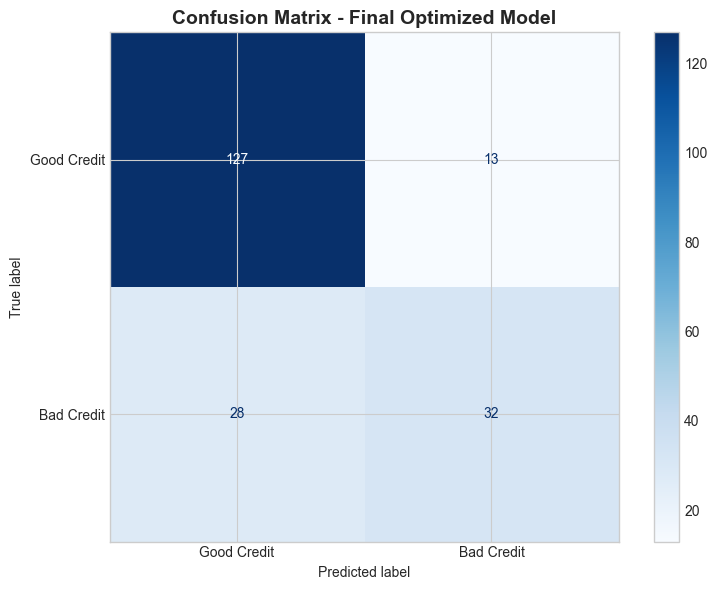

💾 Plot saved to images\roc_curve_final_optimized_model.png


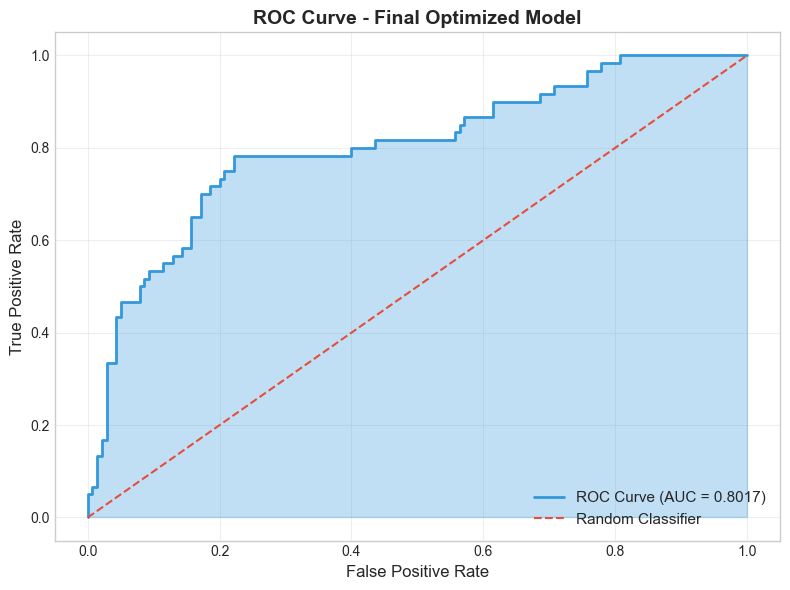

In [7]:
# Confusion Matrix
visualization.plot_confusion_matrix(
    y_test, 
    results['y_pred'], 
    model_name="Final Optimized Model"
)

# ROC Curve
visualization.plot_roc_curve(
    y_test, 
    results['y_prob'], 
    model_name="Final Optimized Model"
)

## 6. Model Persistence

Save the final trained model for future use.

In [11]:
model_path = '../models/logistic_optuna.pkl'
joblib.dump(final_pipeline, model_path)
print(f"✅ Model saved successfully to {model_path}")

✅ Model saved successfully to ../models/logistic_optuna.pkl
